In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('naive_bayes_10000_dataset.csv')
df.isnull().sum()
df.columns

Index(['gender', 'cgpa', 'attendance', 'internship', 'projects',
       'communication', 'aptitude_score', 'coding_score', 'backlogs',
       'extracurricular', 'placed'],
      dtype='object')

In [7]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

cgpa 0
attendance 0
projects 0
aptitude_score 0
coding_score 0
backlogs 0
placed 0


In [20]:
from sklearn.model_selection import train_test_split
X = df.drop('placed', axis=1)
y = df['placed']
yes_no_cols = ['internship', 'extracurricular']
for col in yes_no_cols:
    X[col] = X[col].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

X = pd.get_dummies(X, columns=['communication', 'gender'], drop_first=True)

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



In [23]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print(cm,"\n")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nAccuracy: \n", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[1063   88]
 [ 148  701]] 

Confusion Matrix:
 [[1063   88]
 [ 148  701]]

Accuracy: 
 0.882
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1151
           1       0.89      0.83      0.86       849

    accuracy                           0.88      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.88      0.88      0.88      2000


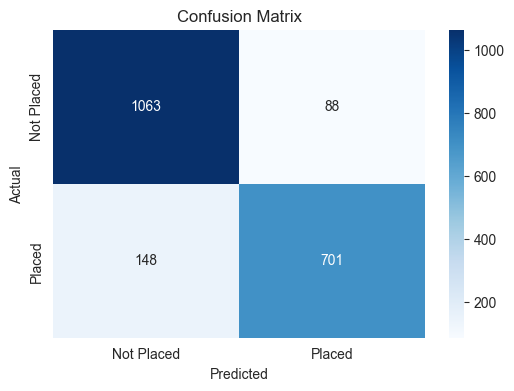

In [42]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Placed','Placed'],
            yticklabels=['Not Placed','Placed'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:\n", cm_lr)
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr))
print("\nReport:\n", classification_report(y_test, y_pred_lr))

Confusion Matrix:
 [[1062   89]
 [  97  752]]

Accuracy: 0.907

Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      1151
           1       0.89      0.89      0.89       849

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000


In [46]:
print("\nPredicted Placed:", sum(y_pred))
print("Predicted Not Placed:", len(y_pred) - sum(y_pred))





Predicted Placed: 789
Predicted Not Placed: 1211
